# LocoSense — Phase 1: Setup & EDA

**Before running:** Make sure VS Code shows `./venv` as the kernel (top-right of this notebook).  
If not → click the kernel selector → *Python Environments* → `venv`.

| | |
|---|---|
| Dataset | `data/raw/locosense_dataset.numbers` |
| Rows | 6,925 |
| Columns | 22 |
| Locos | 50 unique |
| Goal | Load, verify, explore — output `data/processed/locosense_phase1.csv` |

In [10]:
import os
from pathlib import Path
print("RAW cwd:", os.getcwd())
print("RAW resolve:", Path().resolve())
print("RAW parent:", Path().resolve().parent)

RAW cwd: /Users/anshulrathore/Desktop/intern/locosense
RAW resolve: /Users/anshulrathore/Desktop/intern/locosense
RAW parent: /Users/anshulrathore/Desktop/intern


---
## Cell 1 — Imports & path setup

In [11]:
import sys
from pathlib import Path

# ── Make sure we're running inside venv ──────────────────────────────────────
assert 'venv' in sys.executable, (
    "Wrong kernel! Click the kernel selector (top-right) and choose ./venv/bin/python"
)

import warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams.update({'figure.dpi': 120, 'savefig.bbox': 'tight'})

# ── Paths (all relative to notebook location inside notebooks/) ───────────────
NOTEBOOK_DIR  = Path().resolve()
ROOT          = NOTEBOOK_DIR
RAW_DIR       = ROOT / 'data' / 'raw'
PROCESSED_DIR = ROOT / 'data' / 'processed'
FIGURES_DIR   = ROOT / 'reports' / 'figures'

CSV_RAW    = RAW_DIR / 'locosense dataset.csv'
CSV_PHASE1    = PROCESSED_DIR / 'locosense_phase1.csv'

PROCESSED_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

# ── Sanity check ─────────────────────────────────────────────────────────────
assert CSV_RAW.exists(), (
    f"Dataset not found at {CSV_RAW}\n"
    "Make sure locosense dataset.csv is inside data/raw/"
)

print(f'Python  : {sys.version.split()[0]}')
print(f'pandas  : {pd.__version__}')
print(f'numpy   : {np.__version__}')
print(f'Root    : {ROOT}')
print('All imports OK ✓')

Python  : 3.9.6
pandas  : 2.3.3
numpy   : 2.0.2
Root    : /Users/anshulrathore/Desktop/intern/locosense
All imports OK ✓


---
## Cell 2 — Load `.numbers` file → export CSV

In [12]:
# ── Load CSV directly (numbers-parser no longer needed) ──────────────────────
df_raw = pd.read_csv(RAW_DIR / 'locosense dataset.csv')   # ← change filename if yours differs

# Quick check
print(f'Loaded  : {df_raw.shape[0]:,} rows × {df_raw.shape[1]} columns')
print(f'Columns : {list(df_raw.columns)}')
df_raw.head(3)

Loaded  : 6,925 rows × 22 columns
Columns : ['loco id', 'loco type', 'zone', 'manufacture year', 'cycle', 'totalcycles', 'days since service', 'engine temp   (C)', 'oil pressure (bar)', 'vibration    (mms)', 'fuel efficiency (%)', 'coolant temp (C)', 'bearing temp  (C)', 'RPM', 'exhaust temp (C)', 'turbo pressure (bar)', 'load factor (%)', 'battery voltage (V)', 'brake pressure (bar)', 'RU', 'failure label', 'risk category']


,loco id,loco type,zone,manufacture year,cycle,totalcycles,days since service,engine temp (C),oil pressure (bar),vibration (mms),...,bearing temp (C),RPM,exhaust temp (C),turbo pressure (bar),load factor (%),battery voltage (V),brake pressure (bar),RU,failure label,risk category
0,WDG4-1001,WDG4,NR,2014,1,174,-12,78.563,3.379,1.993,...,59.894,917.562,323.872,2.033,76.166,24.098,4.137,173,0,Low
1,WDG4-1001,WDG4,NR,2014,2,174,-10,83.015,3.785,2.354,...,59.337,913.649,325.032,1.775,70.422,23.585,3.951,172,0,Low
2,WDG4-1001,WDG4,NR,2014,3,174,-8,81.256,3.553,1.808,...,63.438,881.074,318.182,1.891,64.320,24.109,4.280,171,0,Low


---
## Cell 3 — Rename columns to snake_case

In [13]:
COLUMN_MAP = {
    'loco id'              : 'loco_id',
    'loco type'            : 'loco_type',
    'zone'                 : 'zone',
    'manufacture year'     : 'manufacture_year',
    'cycle'                : 'cycle',
    'totalcycles'          : 'total_cycles',
    'days since service'   : 'days_since_service',
    'engine temp   (C)'    : 'engine_temp',
    'oil pressure (bar)'   : 'oil_pressure',
    'vibration    (mms)'   : 'vibration',
    'fuel efficiency (%)'  : 'fuel_efficiency',
    'coolant temp (C)'     : 'coolant_temp',
    'bearing temp  (C)'    : 'bearing_temp',
    'RPM'                  : 'rpm',
    'exhaust temp (C)'     : 'exhaust_temp',
    'turbo pressure (bar)' : 'turbo_pressure',
    'load factor (%)'      : 'load_factor',
    'battery voltage (V)'  : 'battery_voltage',
    'brake pressure (bar)' : 'brake_pressure',
    'RU'                   : 'ru',
    'failure label'        : 'failure_label',
    'risk category'        : 'risk_category',
}

df = df_raw.rename(columns=COLUMN_MAP).copy()

# Column groups — used throughout all phases
SENSOR_COLS = [
    'engine_temp', 'oil_pressure', 'vibration', 'fuel_efficiency',
    'coolant_temp', 'bearing_temp', 'rpm', 'exhaust_temp',
    'turbo_pressure', 'load_factor', 'battery_voltage', 'brake_pressure',
]
META_COLS  = ['loco_id', 'loco_type', 'zone', 'manufacture_year', 'cycle', 'total_cycles']
LABEL_COLS = ['ru', 'failure_label', 'risk_category', 'days_since_service']

print('Columns after rename:')
for col in df.columns:
    print(f'  {col:<25} {df[col].dtype}')

Columns after rename:
  loco_id                   object
  loco_type                 object
  zone                      object
  manufacture_year          int64
  cycle                     int64
  total_cycles              int64
  days_since_service        int64
  engine_temp               float64
  oil_pressure              float64
  vibration                 float64
  fuel_efficiency           float64
  coolant_temp              float64
  bearing_temp              float64
  rpm                       float64
  exhaust_temp              float64
  turbo_pressure            float64
  load_factor               float64
  battery_voltage           float64
  brake_pressure            float64
  ru                        int64
  failure_label             int64
  risk_category             object


---
## Cell 4 — Data quality checks

In [14]:
print('─' * 45)
print('NULL CHECK')
print('─' * 45)
nulls = df.isnull().sum()
if nulls.sum() == 0:
    print('No nulls — dataset is complete ✓')
else:
    print(nulls[nulls > 0])

print()
print('─' * 45)
print('DUPLICATE ROWS')
print('─' * 45)
dupes = df.duplicated().sum()
print(f'{dupes} duplicate rows' if dupes else 'No duplicate rows ✓')

print()
print('─' * 45)
print('DUPLICATE (loco_id + cycle) PAIRS')
print('─' * 45)
id_cycle_dupes = df.duplicated(subset=['loco_id', 'cycle']).sum()
print(f'{id_cycle_dupes} duplicates' if id_cycle_dupes else 'All pairs unique ✓')

print()
print('─' * 45)
print('days_since_service — NEGATIVE VALUE CHECK')
print('─' * 45)
neg = df[df['days_since_service'] < 0]
print(f'{len(neg)} rows with negative values')
print(f'Range: {df["days_since_service"].min():.0f}  to  {df["days_since_service"].max():.0f}')
print('Note: negatives likely mean days BEFORE next scheduled service')

print()
print('─' * 45)
print('manufacture_year RANGE')
print('─' * 45)
print(f'{int(df["manufacture_year"].min())}  to  {int(df["manufacture_year"].max())} ✓')

─────────────────────────────────────────────
NULL CHECK
─────────────────────────────────────────────
No nulls — dataset is complete ✓

─────────────────────────────────────────────
DUPLICATE ROWS
─────────────────────────────────────────────
No duplicate rows ✓

─────────────────────────────────────────────
DUPLICATE (loco_id + cycle) PAIRS
─────────────────────────────────────────────
All pairs unique ✓

─────────────────────────────────────────────
days_since_service — NEGATIVE VALUE CHECK
─────────────────────────────────────────────
441 rows with negative values
Range: -38  to  180
Note: negatives likely mean days BEFORE next scheduled service

─────────────────────────────────────────────
manufacture_year RANGE
─────────────────────────────────────────────
2010  to  2020 ✓


---
## Cell 5 — Fleet overview

Unique locomotives : 50
Loco types         : ['WAG9', 'WAP5', 'WAP7', 'WDG4', 'WDP4B']
Railway zones      : ['CR', 'ER', 'NR', 'SR', 'WR']



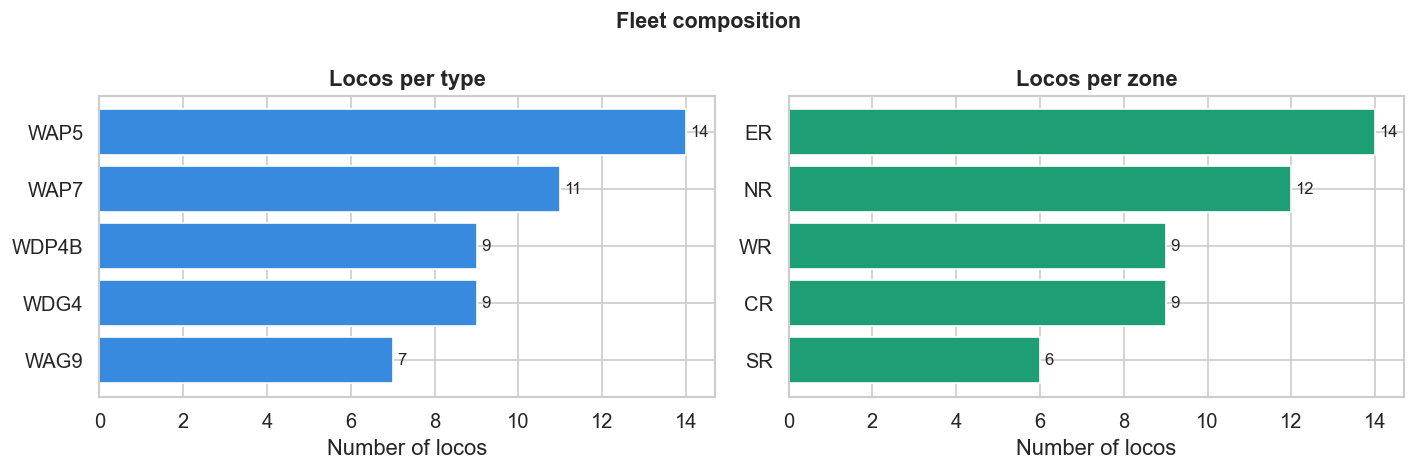

Saved → reports/figures/fleet_overview.png


In [15]:
print(f'Unique locomotives : {df["loco_id"].nunique()}')
print(f'Loco types         : {sorted(df["loco_type"].unique())}')
print(f'Railway zones      : {sorted(df["zone"].unique())}')
print()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Locos per type
type_counts = df.groupby('loco_type')['loco_id'].nunique().sort_values(ascending=True)
axes[0].barh(type_counts.index, type_counts.values, color='#378ADD')
axes[0].set_title('Locos per type', fontweight='bold')
axes[0].set_xlabel('Number of locos')
for i, v in enumerate(type_counts.values):
    axes[0].text(v + 0.1, i, str(v), va='center', fontsize=10)

# Locos per zone
zone_counts = df.groupby('zone')['loco_id'].nunique().sort_values(ascending=True)
axes[1].barh(zone_counts.index, zone_counts.values, color='#1D9E75')
axes[1].set_title('Locos per zone', fontweight='bold')
axes[1].set_xlabel('Number of locos')
for i, v in enumerate(zone_counts.values):
    axes[1].text(v + 0.1, i, str(v), va='center', fontsize=10)

plt.suptitle('Fleet composition', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'fleet_overview.png')
plt.show()
print('Saved → reports/figures/fleet_overview.png')

---
## Cell 6 — Label distributions

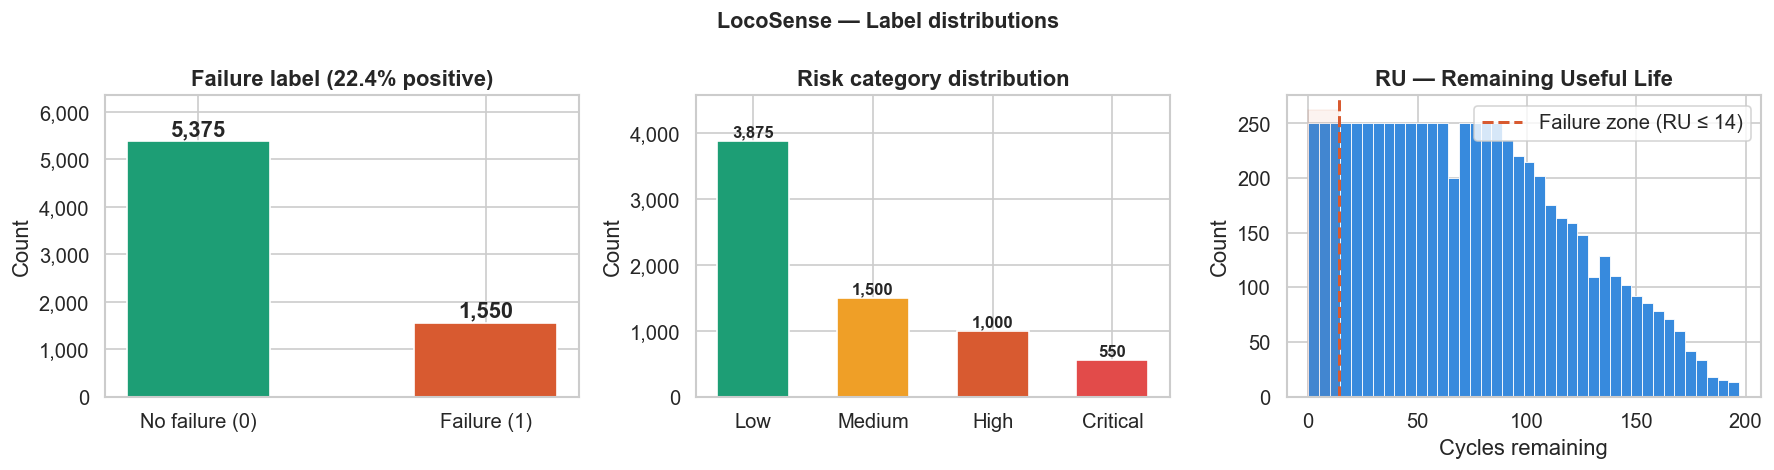

Saved → reports/figures/label_distributions.png


In [16]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# ── Failure label ─────────────────────────────────────────────────────────────
ax = axes[0]
counts = df['failure_label'].value_counts().sort_index()
bars = ax.bar(['No failure (0)', 'Failure (1)'],
              counts.values, color=['#1D9E75', '#D85A30'], width=0.5)
for bar, val in zip(bars, counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 40,
            f'{val:,}', ha='center', va='bottom', fontweight='bold')
failure_pct = counts.get(1.0, 0) / counts.sum() * 100
ax.set_title(f'Failure label ({failure_pct:.1f}% positive)', fontweight='bold')
ax.set_ylabel('Count')
ax.set_ylim(0, counts.max() * 1.18)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

# ── Risk category ─────────────────────────────────────────────────────────────
ax = axes[1]
risk_order  = ['Low', 'Medium', 'High', 'Critical']
risk_colors = ['#1D9E75', '#EF9F27', '#D85A30', '#E24B4A']
risk_counts = df['risk_category'].value_counts().reindex(risk_order)
bars = ax.bar(risk_order, risk_counts.values, color=risk_colors, width=0.6)
for bar, val in zip(bars, risk_counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 20,
            f'{val:,}', ha='center', va='bottom', fontweight='bold', fontsize=10)
ax.set_title('Risk category distribution', fontweight='bold')
ax.set_ylabel('Count')
ax.set_ylim(0, risk_counts.max() * 1.18)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

# ── RU histogram ─────────────────────────────────────────────────────────────
ax = axes[2]
ax.hist(df['ru'], bins=40, color='#378ADD', edgecolor='white', linewidth=0.5)
ax.axvline(14, color='#D85A30', linestyle='--', linewidth=1.8,
           label='Failure zone (RU ≤ 14)')
ax.fill_between([0, 14], 0, ax.get_ylim()[1] if ax.get_ylim()[1] > 0 else 600,
                color='#D85A30', alpha=0.07)
ax.set_title('RU — Remaining Useful Life', fontweight='bold')
ax.set_xlabel('Cycles remaining')
ax.set_ylabel('Count')
ax.legend()

plt.suptitle('LocoSense — Label distributions', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'label_distributions.png')
plt.show()
print('Saved → reports/figures/label_distributions.png')

---
## Cell 7 — Risk category × failure label cross-tab

In [17]:
cross = pd.crosstab(
    df['risk_category'], df['failure_label'],
    margins=True
)
cross.columns = ['No failure (0)', 'Failure (1)', 'Total']
cross['Failure rate %'] = (cross['Failure (1)'] / cross['Total'] * 100).round(1)

# Reorder rows
order = ['Low', 'Medium', 'High', 'Critical', 'All']
cross = cross.reindex([o for o in order if o in cross.index])

print('Risk category × Failure label')
print(cross.to_string())
print()
print('Key insight: Critical category should have 100% failure rate — verify alignment.')

Risk category × Failure label
               No failure (0)  Failure (1)  Total  Failure rate %
risk_category                                                    
Low                      3875            0   3875             0.0
Medium                   1500            0   1500             0.0
High                        0         1000   1000           100.0
Critical                    0          550    550           100.0
All                      5375         1550   6925            22.4

Key insight: Critical category should have 100% failure rate — verify alignment.


---
## Cell 8 — Sensor statistics

In [18]:
print('Sensor summary statistics')
print(df[SENSOR_COLS].describe().round(3).to_string())

Sensor summary statistics
       engine_temp  oil_pressure  vibration  fuel_efficiency  coolant_temp  bearing_temp       rpm  exhaust_temp  turbo_pressure  load_factor  battery_voltage  brake_pressure
count     6925.000      6925.000   6925.000         6925.000      6925.000      6925.000  6925.000      6925.000        6925.000     6925.000         6925.000        6925.000
mean        89.295         3.074      2.887           90.997        79.934        64.568   881.364       335.083           1.588       72.112           23.391           3.896
std         11.316         0.601      1.656            4.695         7.748         7.515    34.648        24.387           0.300        4.947            0.995           0.461
min         73.677         0.609      0.896           70.083        66.197        53.425   694.403       286.577           0.500       53.291           18.633           1.928
25%         82.659         3.035      1.943           90.420        75.241        60.165   866.689 

---
## Cell 9 — Sensor distributions: no-failure vs failure

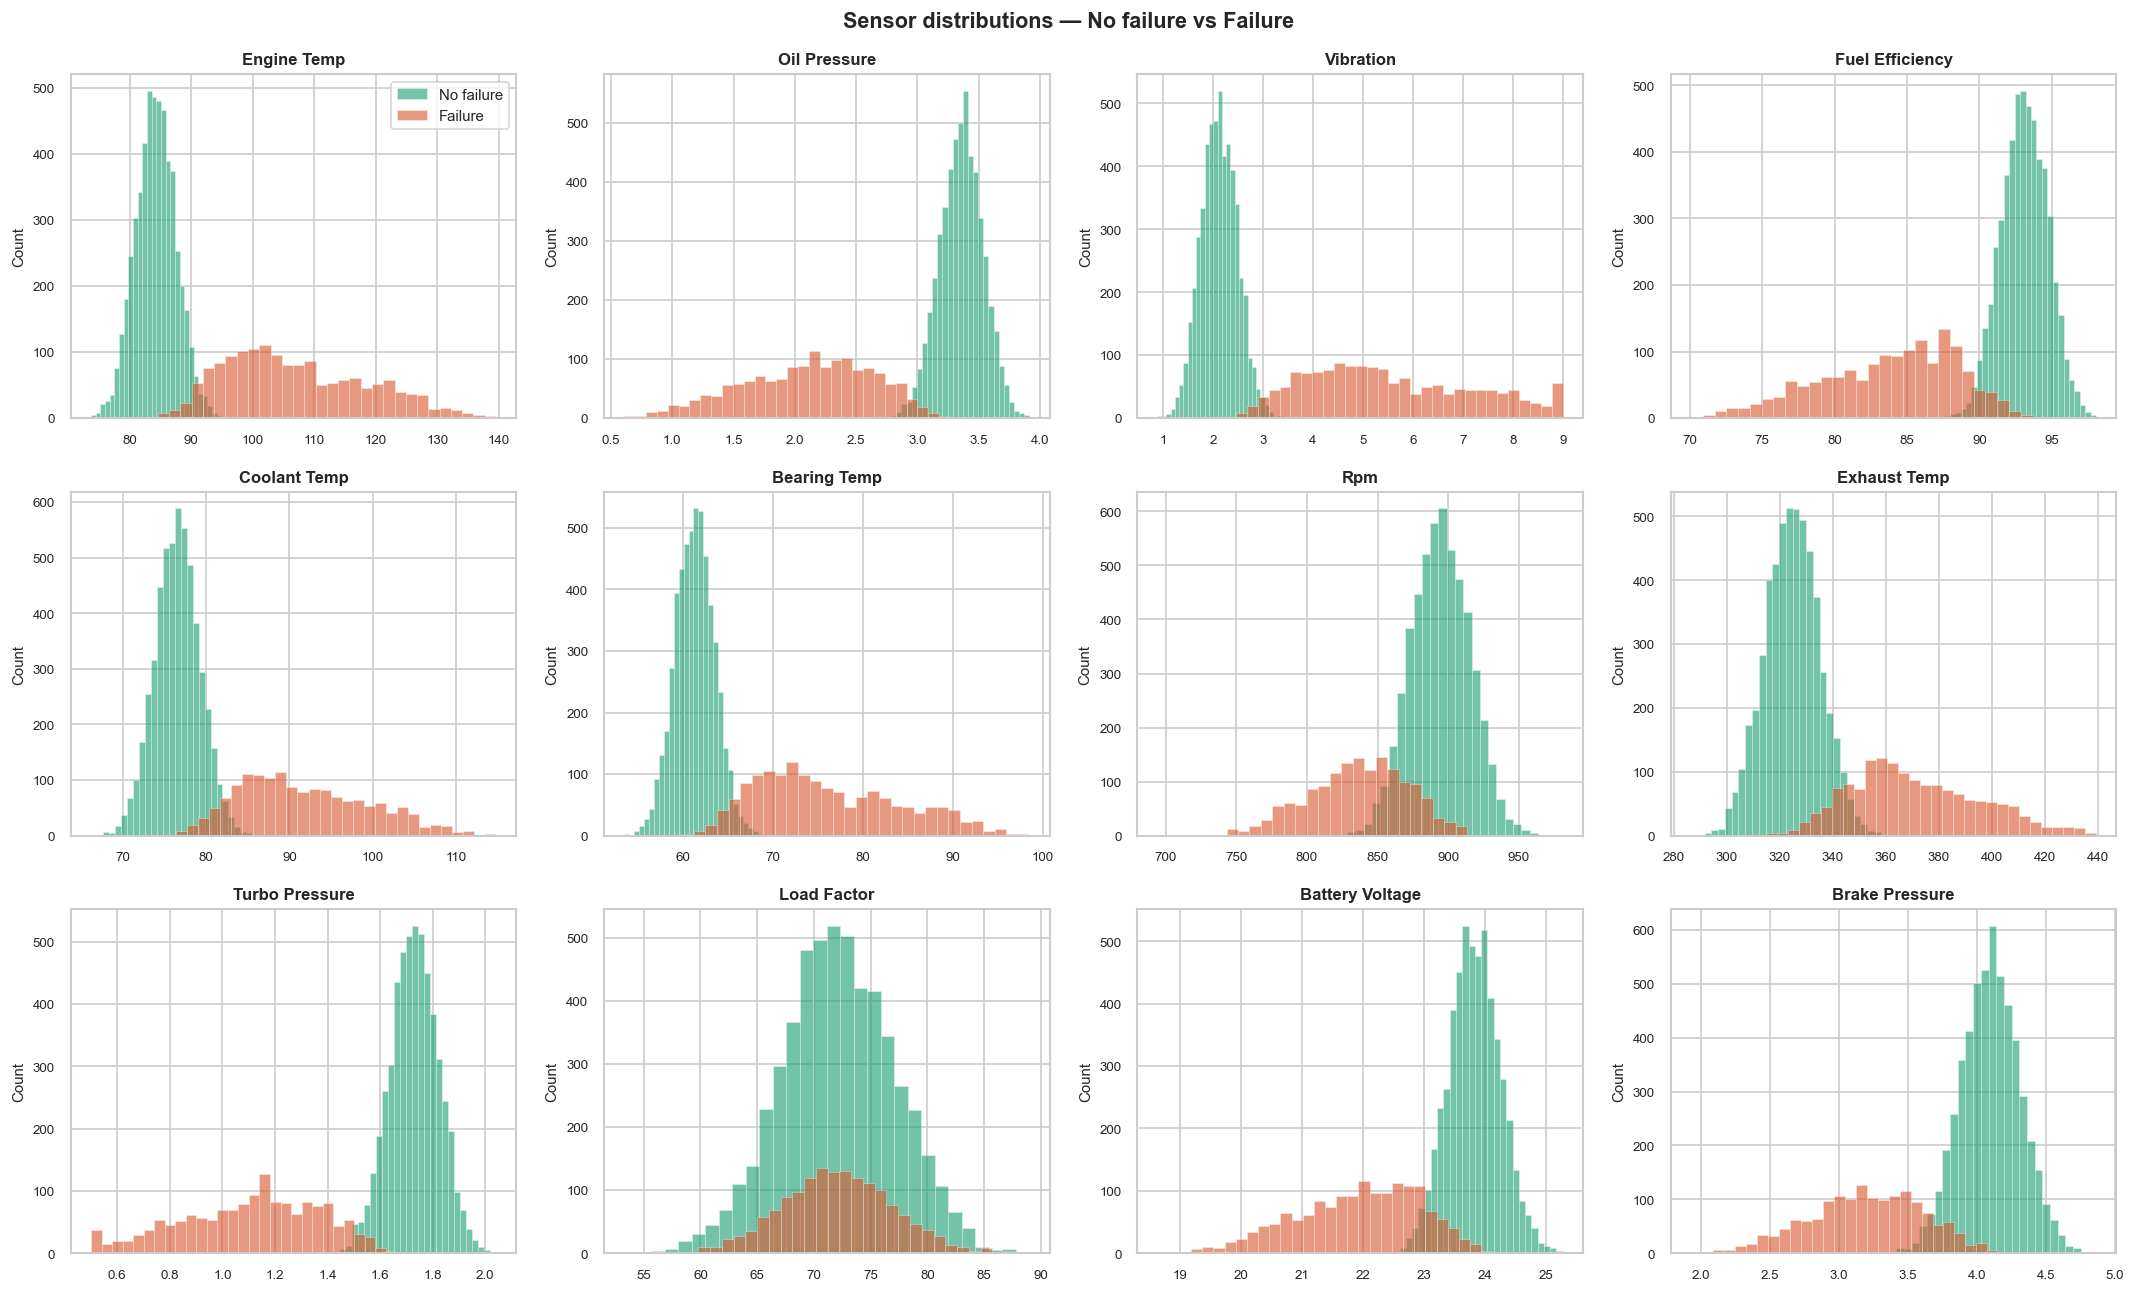

Saved → reports/figures/sensor_distributions.png


In [19]:
fig, axes = plt.subplots(3, 4, figsize=(18, 11))
axes = axes.flatten()

palette = {0.0: '#1D9E75', 1.0: '#D85A30'}
label_map = {0.0: 'No failure', 1.0: 'Failure'}

for i, col in enumerate(SENSOR_COLS):
    ax = axes[i]
    for lval, color in palette.items():
        subset = df[df['failure_label'] == lval][col]
        ax.hist(subset, bins=30, alpha=0.62, color=color,
                label=label_map[lval], edgecolor='white', linewidth=0.3)
    ax.set_title(col.replace('_', ' ').title(), fontsize=10, fontweight='bold')
    ax.set_ylabel('Count', fontsize=9)
    ax.tick_params(labelsize=8)
    if i == 0:
        ax.legend(fontsize=9)

plt.suptitle('Sensor distributions — No failure vs Failure', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'sensor_distributions.png')
plt.show()
print('Saved → reports/figures/sensor_distributions.png')

---
## Cell 10 — Correlation heatmap

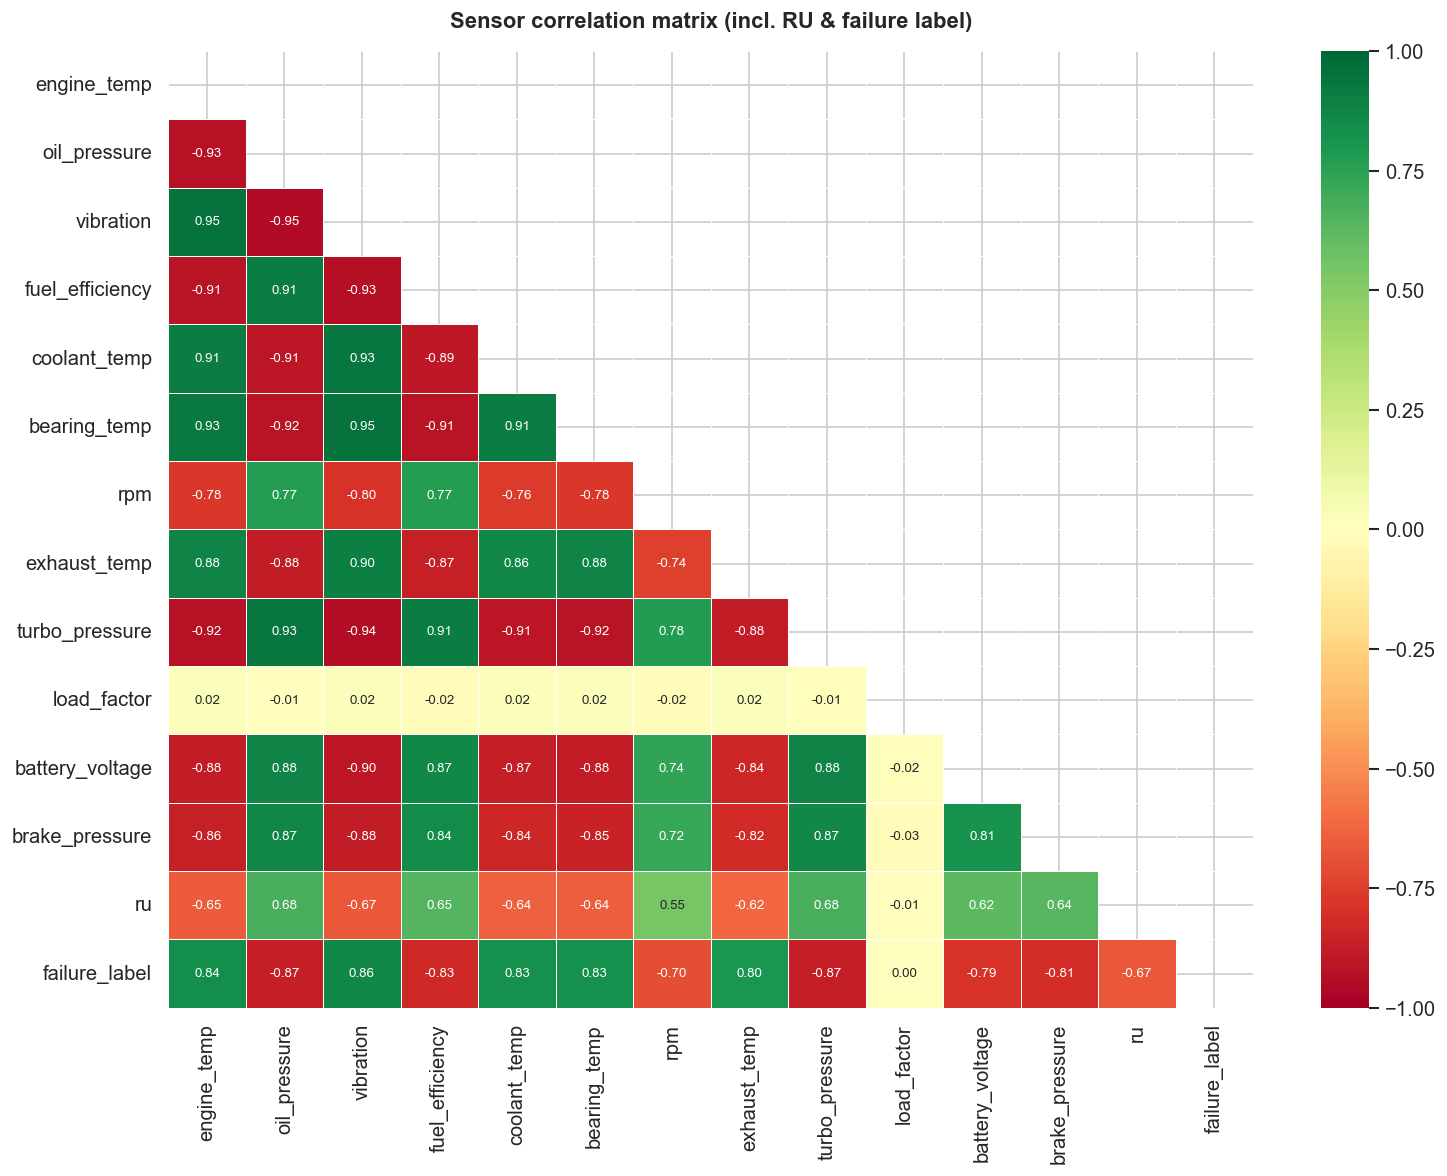

Saved → reports/figures/correlation_heatmap.png


In [20]:
fig, ax = plt.subplots(figsize=(13, 10))

corr_cols = SENSOR_COLS + ['ru', 'failure_label']
corr = df[corr_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))

sns.heatmap(
    corr, mask=mask, annot=True, fmt='.2f',
    cmap='RdYlGn', center=0, vmin=-1, vmax=1,
    linewidths=0.5, linecolor='white',
    annot_kws={'size': 8}, ax=ax
)
ax.set_title('Sensor correlation matrix (incl. RU & failure label)',
             fontweight='bold', pad=14)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'correlation_heatmap.png')
plt.show()
print('Saved → reports/figures/correlation_heatmap.png')

---
## Cell 11 — RU trend for 6 sample locomotives

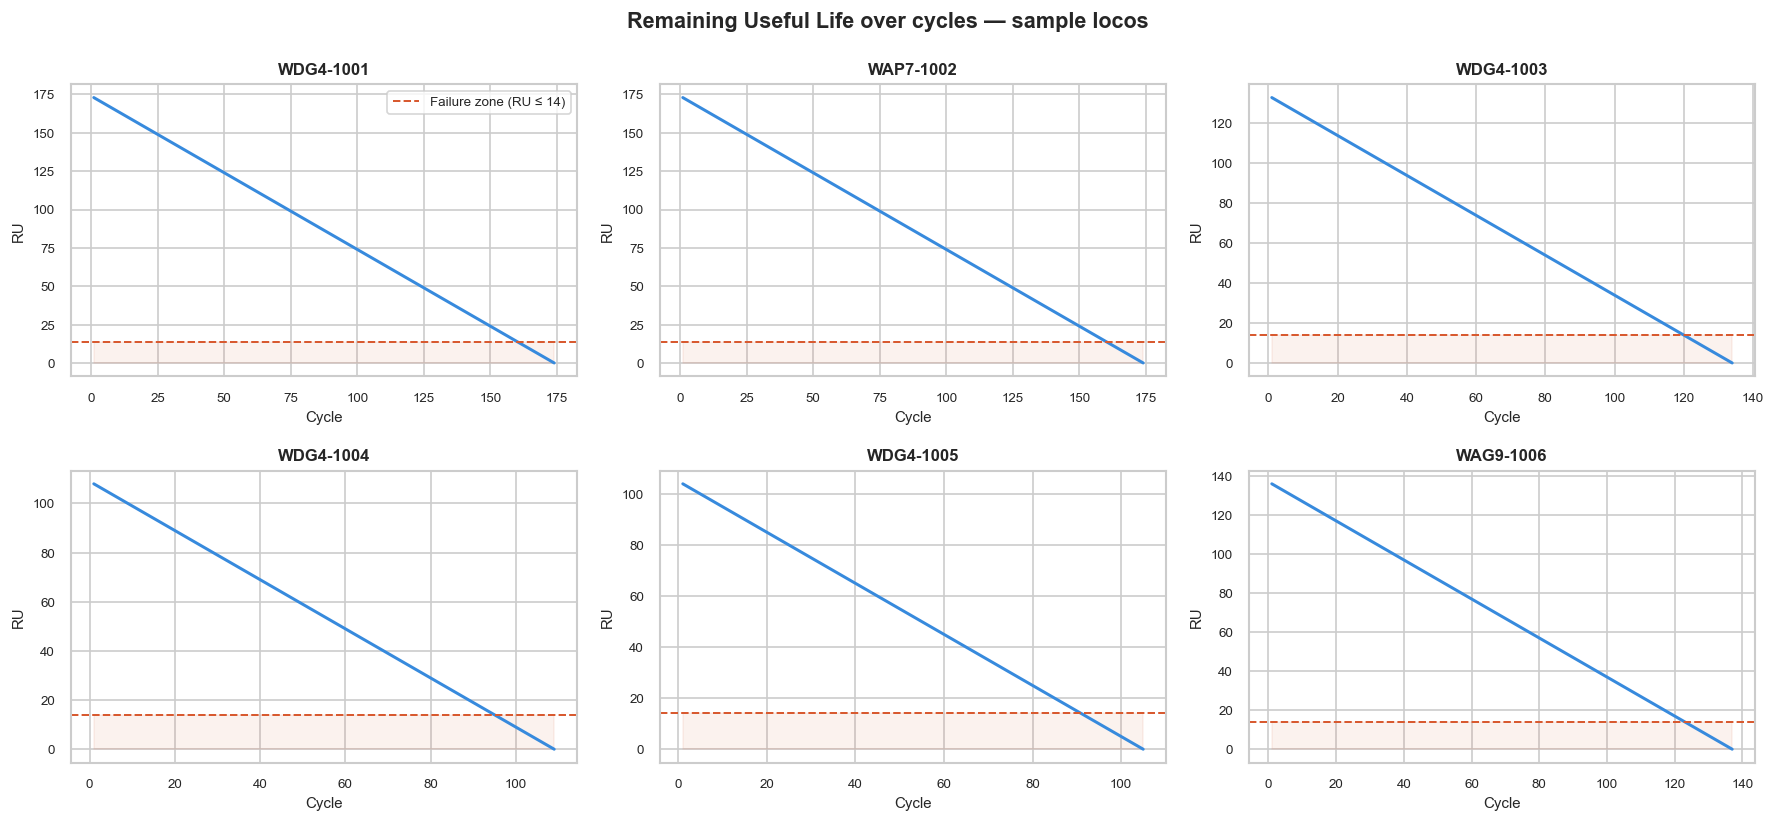

Saved → reports/figures/ru_trends.png


In [21]:
sample_locos = df['loco_id'].unique()[:6]
fig, axes    = plt.subplots(2, 3, figsize=(15, 7))
axes         = axes.flatten()

for i, loco in enumerate(sample_locos):
    ax      = axes[i]
    loco_df = df[df['loco_id'] == loco].sort_values('cycle')

    ax.plot(loco_df['cycle'], loco_df['ru'],
            color='#378ADD', linewidth=1.8)
    ax.axhline(14, color='#D85A30', linestyle='--', linewidth=1.2,
               label='Failure zone (RU ≤ 14)')
    ax.fill_between(loco_df['cycle'], 0, 14, color='#D85A30', alpha=0.08)

    ax.set_title(loco, fontsize=10, fontweight='bold')
    ax.set_xlabel('Cycle', fontsize=9)
    ax.set_ylabel('RU', fontsize=9)
    ax.tick_params(labelsize=8)
    if i == 0:
        ax.legend(fontsize=8)

plt.suptitle('Remaining Useful Life over cycles — sample locos',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'ru_trends.png')
plt.show()
print('Saved → reports/figures/ru_trends.png')

---
## Cell 12 — Save processed file & Phase 1 summary

In [22]:
# Save with clean column names for Phase 2
df.to_csv(CSV_PHASE1, index=False)

n_neg = (df['days_since_service'] < 0).sum()
spw   = round((df['failure_label'] == 0).sum() / (df['failure_label'] == 1).sum(), 2)

print('=' * 55)
print('  PHASE 1 COMPLETE')
print('=' * 55)
print(f'  Rows              : {len(df):,}')
print(f'  Columns           : {df.shape[1]}')
print(f'  Unique locos      : {df["loco_id"].nunique()}')
print(f'  Loco types        : {sorted(df["loco_type"].unique())}')
print(f'  Railway zones     : {sorted(df["zone"].unique())}')
print(f'  Nulls             : {df.isnull().sum().sum()}')
print(f'  Failure rate      : {df["failure_label"].mean()*100:.1f}%')
print(f'  scale_pos_weight  : {spw}  ← use this in XGBoost Phase 3')
print(f'  RU range          : {int(df["ru"].min())} – {int(df["ru"].max())} cycles')
print(f'  Risk categories   : {sorted(df["risk_category"].unique())}')
print()
print('  FLAGS FOR PHASE 2')
print(f'  [!] {n_neg} rows with negative days_since_service')
print( '      Decision: clip at 0 OR treat as pre-service window feature')
print( '  [!] 4 risk categories — decide binary vs 4-class in Phase 3')
print( '  [i] RU + failure_label already computed — skip label engineering')
print( '  [i] No nulls — no imputation step needed')
print()
print(f'  Output: data/processed/locosense_phase1.csv')
print(f'  Plots : reports/figures/ (4 files)')
print('=' * 55)

  PHASE 1 COMPLETE
  Rows              : 6,925
  Columns           : 22
  Unique locos      : 50
  Loco types        : ['WAG9', 'WAP5', 'WAP7', 'WDG4', 'WDP4B']
  Railway zones     : ['CR', 'ER', 'NR', 'SR', 'WR']
  Nulls             : 0
  Failure rate      : 22.4%
  scale_pos_weight  : 3.47  ← use this in XGBoost Phase 3
  RU range          : 0 – 197 cycles
  Risk categories   : ['Critical', 'High', 'Low', 'Medium']

  FLAGS FOR PHASE 2
  [!] 441 rows with negative days_since_service
      Decision: clip at 0 OR treat as pre-service window feature
  [!] 4 risk categories — decide binary vs 4-class in Phase 3
  [i] RU + failure_label already computed — skip label engineering
  [i] No nulls — no imputation step needed

  Output: data/processed/locosense_phase1.csv
  Plots : reports/figures/ (4 files)
